In [3]:
import os
import glob
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

In [5]:
DATA_DIR = "/home/zahin/Desktop/AI_LAB/final_assignment/dataset2"   # your folder with subfolders 0..9
IMG_SIZE = (28, 28)     # resize to this (MNIST standard)
RANDOM_SEED = 42
EPOCHS = 15
BATCH_SIZE = 128
NUM_CLASSES = 10

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [6]:
def load_local_digit_dataset(data_dir, img_size=(28,28)):
    patterns = []
    exts = ["png", "jpg", "jpeg", "bmp", "tiff"]
    for label in range(10):
        for ext in exts:
            patterns.append(os.path.join(data_dir, str(label), f"*.{ext}"))
    paths = []
    for p in patterns:
        paths.extend(glob.glob(p))
    images = []
    labels = []
    if not paths:
        raise FileNotFoundError(f"No images found in {data_dir}. Check path and extensions.")
    for p in paths:
        try:
            img = Image.open(p).convert("L")  # grayscale
            img = img.resize(img_size, Image.LANCZOS)
            arr = np.asarray(img, dtype=np.float32) / 255.0  # normalize to [0,1]
            images.append(arr)
            lbl = int(os.path.basename(os.path.dirname(p)))
            labels.append(lbl)
        except Exception as e:
            print(f"Warning: could not read {p}: {e}")
    images = np.array(images)  # shape (N, H, W)
    labels = np.array(labels, dtype=np.int64)
    return images, labels

In [7]:
print("Loading local dataset from:", DATA_DIR)
x_local, y_local = load_local_digit_dataset(DATA_DIR, IMG_SIZE)
print("Local dataset shape:", x_local.shape, y_local.shape)

Loading local dataset from: /home/zahin/Desktop/AI_LAB/final_assignment/dataset2
Local dataset shape: (501, 28, 28) (501,)


In [8]:
x_train_local, x_test_local, y_train_local, y_test_local = train_test_split(
    x_local, y_local, test_size=0.20, stratify=y_local, random_state=RANDOM_SEED
)
print("Local train/test shapes:", x_train_local.shape, x_test_local.shape)

Local train/test shapes: (400, 28, 28) (101, 28, 28)


In [12]:
print("Loading MNIST dataset from keras.datasets")
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()
# normalize
mnist_x_train = mnist_x_train.astype(np.float32) / 255.0
mnist_x_test = mnist_x_test.astype(np.float32) / 255.0
print("MNIST shapes:", mnist_x_train.shape, mnist_x_test.shape)

Loading MNIST dataset from keras.datasets
MNIST shapes: (60000, 28, 28) (10000, 28, 28)


In [13]:
y_train_local_cat = to_categorical(y_train_local, NUM_CLASSES)
y_test_local_cat = to_categorical(y_test_local, NUM_CLASSES)
mnist_y_train_cat = to_categorical(mnist_y_train, NUM_CLASSES)
mnist_y_test_cat = to_categorical(mnist_y_test, NUM_CLASSES)

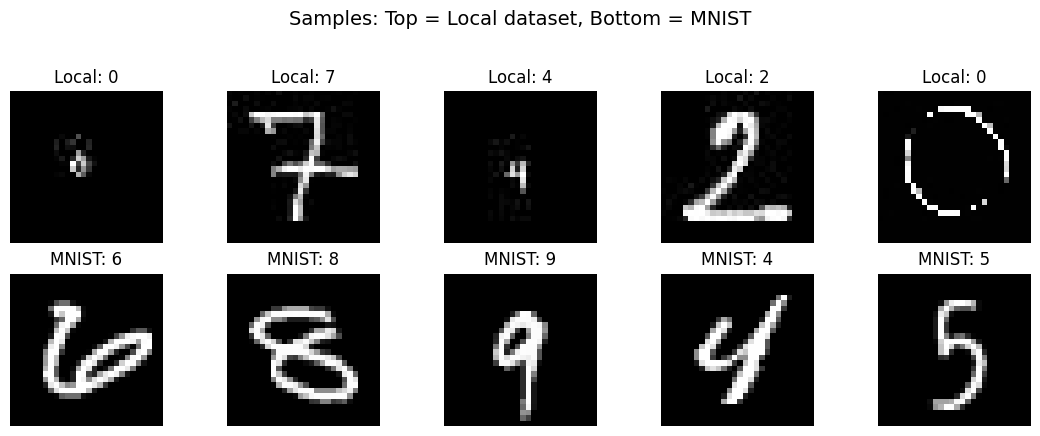

In [14]:
def plot_samples(local_images, local_labels, mnist_images, mnist_labels, n=5):
    fig, axes = plt.subplots(2, n, figsize=(n*2.2, 4.4))
    fig.suptitle("Samples: Top = Local dataset, Bottom = MNIST", fontsize=14)
    idxs_local = np.random.choice(len(local_images), size=n, replace=False)
    idxs_mnist = np.random.choice(len(mnist_images), size=n, replace=False)
    for i, ax in enumerate(axes[0]):
        ax.imshow(local_images[idxs_local[i]], cmap='gray')
        ax.axis('off')
        ax.set_title(f"Local: {local_labels[idxs_local[i]]}")
    for i, ax in enumerate(axes[1]):
        ax.imshow(mnist_images[idxs_mnist[i]], cmap='gray')
        ax.axis('off')
        ax.set_title(f"MNIST: {mnist_labels[idxs_mnist[i]]}")
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

plot_samples(x_train_local, y_train_local, mnist_x_train, mnist_y_train, n=5)

In [15]:
def build_fcf_nn(input_shape=(28,28), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# instantiate one model and print summary
model = build_fcf_nn(input_shape=IMG_SIZE, num_classes=NUM_CLASSES)
print("\nFCFNN summary:")
model.summary()


FCFNN summary:


2026-02-23 12:53:19.010778: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
def train_model(x_train, y_train_cat, desc="dataset", epochs=EPOCHS, batch_size=BATCH_SIZE):
    print(f"\nTraining on {desc} | samples={len(x_train)}")
    hist = model.__class__.from_config(model.get_config())  # wrong approach, recreate properly
    # instead create fresh model to avoid re-use issues
    m = build_fcf_nn(input_shape=IMG_SIZE, num_classes=NUM_CLASSES)
    history = m.fit(
        x_train, y_train_cat,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=2
    )
    return m, history


In [21]:
x_train_local_arr = x_train_local.astype(np.float32)
x_test_local_arr = x_test_local.astype(np.float32)

# MNIST arrays are already float32
x_train_mnist_arr = mnist_x_train
x_test_mnist_arr = mnist_x_test

x_train_combined = np.concatenate([x_train_local_arr, x_train_mnist_arr], axis=0)
y_train_combined_cat = np.concatenate([y_train_local_cat, mnist_y_train_cat], axis=0)
print("Combined train shape:", x_train_combined.shape, y_train_combined_cat.shape)

model_combined = build_fcf_nn(input_shape=IMG_SIZE, num_classes=NUM_CLASSES)

Combined train shape: (60400, 28, 28) (60400, 10)


In [22]:
history_combined = model_combined.fit(
    x_train_combined,
    y_train_combined_cat,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

Epoch 1/15
378/378 - 3s - 7ms/step - accuracy: 0.8884 - loss: 0.3669 - val_accuracy: 0.9578 - val_loss: 0.1400
Epoch 2/15
378/378 - 2s - 5ms/step - accuracy: 0.9497 - loss: 0.1641 - val_accuracy: 0.9685 - val_loss: 0.1033
Epoch 3/15
378/378 - 2s - 5ms/step - accuracy: 0.9640 - loss: 0.1180 - val_accuracy: 0.9719 - val_loss: 0.0918
Epoch 4/15
378/378 - 2s - 5ms/step - accuracy: 0.9704 - loss: 0.0960 - val_accuracy: 0.9762 - val_loss: 0.0792
Epoch 5/15
378/378 - 2s - 5ms/step - accuracy: 0.9745 - loss: 0.0814 - val_accuracy: 0.9765 - val_loss: 0.0816
Epoch 6/15
378/378 - 2s - 5ms/step - accuracy: 0.9774 - loss: 0.0698 - val_accuracy: 0.9780 - val_loss: 0.0802
Epoch 7/15
378/378 - 2s - 5ms/step - accuracy: 0.9811 - loss: 0.0610 - val_accuracy: 0.9784 - val_loss: 0.0766
Epoch 8/15
378/378 - 2s - 5ms/step - accuracy: 0.9815 - loss: 0.0585 - val_accuracy: 0.9783 - val_loss: 0.0763
Epoch 9/15
378/378 - 2s - 5ms/step - accuracy: 0.9833 - loss: 0.0528 - val_accuracy: 0.9797 - val_loss: 0.0749
E

In [23]:
def plot_histories(histories, labels):
    # histories: list of keras History objects
    plt.figure(figsize=(12,8))

    # Accuracy
    plt.subplot(2,1,1)
    for h, lab in zip(histories, labels):
        plt.plot(h.history['accuracy'], label=f'{lab} train acc')
        plt.plot(h.history['val_accuracy'], linestyle='--', label=f'{lab} val acc')
    plt.title('Training & Validation Accuracy')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    # Loss
    plt.subplot(2,1,2)
    for h, lab in zip(histories, labels):
        plt.plot(h.history['loss'], label=f'{lab} train loss')
        plt.plot(h.history['val_loss'], linestyle='--', label=f'{lab} val loss')
    plt.title('Training & Validation Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


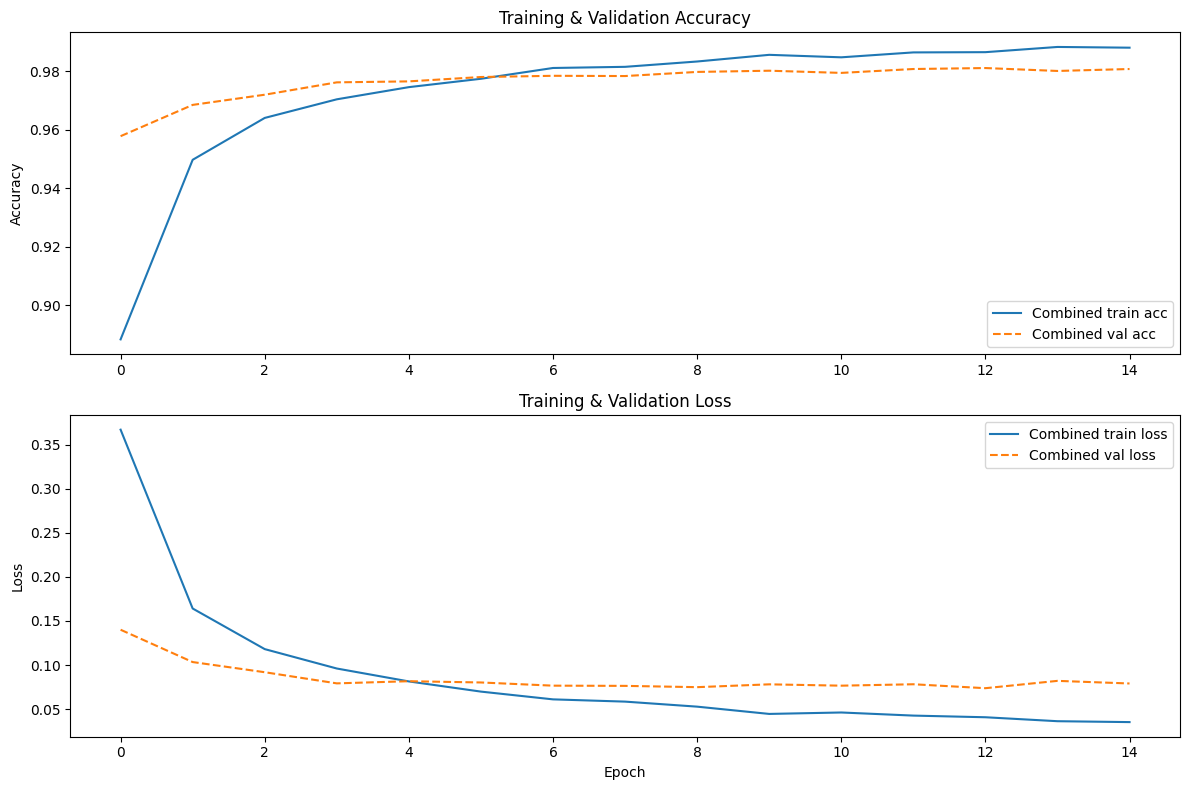

In [24]:
plot_histories([history_combined],
               ['Combined'])

In [25]:
print("\nEvaluating combined model on local test set:")
loss_local, acc_local = model_combined.evaluate(x_test_local_arr, y_test_local_cat, verbose=0)
print(f"Local test -> Loss: {loss_local:.4f}, Accuracy: {acc_local:.4f}")

print("\nEvaluating combined model on MNIST test set:")
loss_mnist, acc_mnist = model_combined.evaluate(x_test_mnist_arr, mnist_y_test_cat, verbose=0)
print(f"MNIST test -> Loss: {loss_mnist:.4f}, Accuracy: {acc_mnist:.4f}")


Evaluating combined model on local test set:
Local test -> Loss: 0.3372, Accuracy: 0.9307

Evaluating combined model on MNIST test set:
MNIST test -> Loss: 0.0623, Accuracy: 0.9834


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


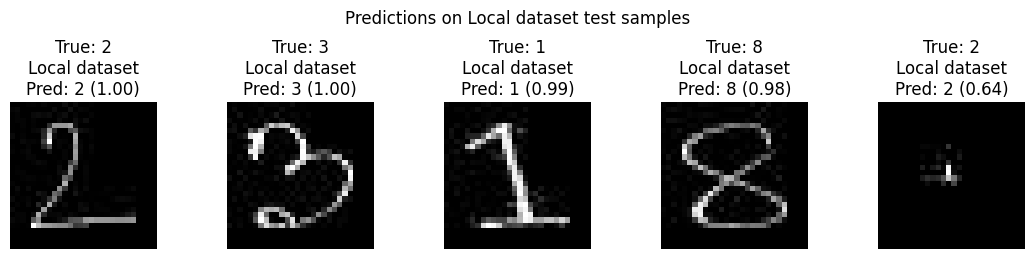

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


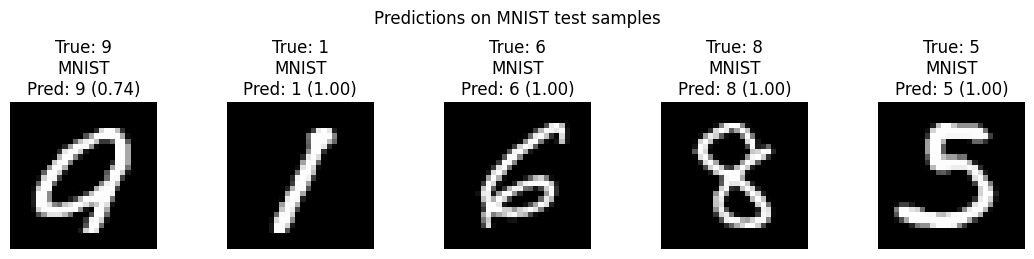

In [26]:
def plot_predictions(model, images, true_labels, dataset_name, n=5):
    idxs = np.random.choice(len(images), size=n, replace=False)
    preds = model.predict(images[idxs])
    pred_labels = np.argmax(preds, axis=1)
    pred_probs = np.max(preds, axis=1)
    fig, axes = plt.subplots(1, n, figsize=(n*2.2, 2.6))
    for i, ax in enumerate(axes):
        ax.imshow(images[idxs[i]], cmap='gray')
        ax.axis('off')
        ax.set_title(f"True: {true_labels[idxs[i]]}\n{dataset_name}\nPred: {pred_labels[i]} ({pred_probs[i]:.2f})")
    plt.suptitle(f"Predictions on {dataset_name} test samples", fontsize=12)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

plot_predictions(model_combined, x_test_local_arr, y_test_local, "Local dataset", n=5)
plot_predictions(model_combined, x_test_mnist_arr, mnist_y_test, "MNIST", n=5)